In [1]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2

from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


In [2]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../../../../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup

from spikeml.ui.ipywidgets_ui import ui

from spikeml.datasets.dataset import SimpleDataset, DataLoader
from spikeml.datasets.encoder import one_hot
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs


from spikeml.utils.vector import normalize, normalize_all

from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb




(8, 8, 3)


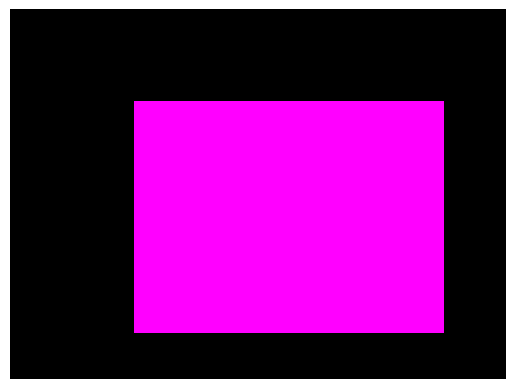

<Axes: >

In [3]:
shape=(8,8,3)
a = np.zeros(shape, dtype=np.uint8)
w,h = a.shape[1],a.shape[0]
color = (255,0,255)
cv2.rectangle(a, (w//4,h//4), (3*w//4,3*h//4), color=color, thickness=-1)
print(a.shape)
show_img(a)


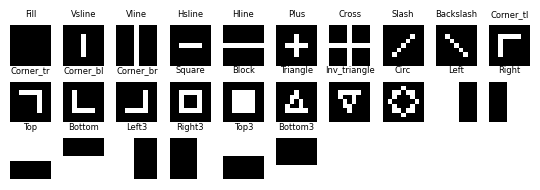

In [23]:
    
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs

aa = make_glyphs(shape=(9,9))

titles = [str(g) for g in Glyph ]
show_glyphs(aa, titles=titles, pad=0.3)



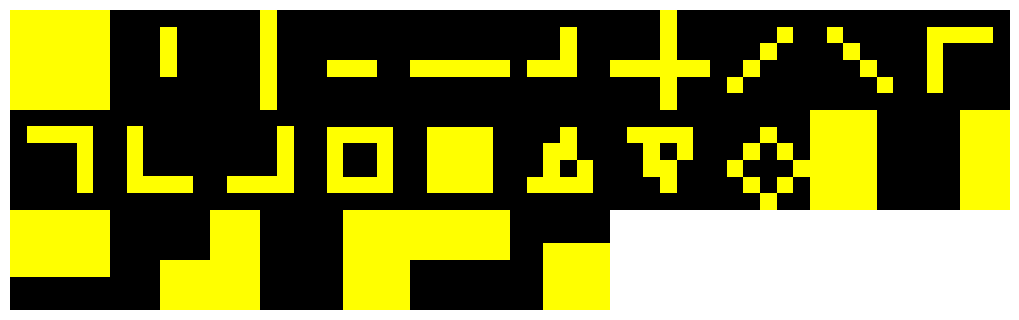

In [5]:
aa = make_glyphs(shape=(6,6,3), color=(255,255,0))
#aa = [a/ a.sum()*a.size for a in aa ]
show_glyphs(aa)

(5, 5)
[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 0. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]
[[0.    0.    0.    0.    0.   ]
 [0.    0.125 0.125 0.125 0.   ]
 [0.    0.125 0.    0.125 0.   ]
 [0.    0.125 0.125 0.125 0.   ]
 [0.    0.    0.    0.    0.   ]]
[[0.         0.         0.         0.         0.        ]
 [0.         0.35355339 0.35355339 0.35355339 0.        ]
 [0.         0.35355339 0.         0.35355339 0.        ]
 [0.         0.35355339 0.35355339 0.35355339 0.        ]
 [0.         0.         0.         0.         0.        ]]


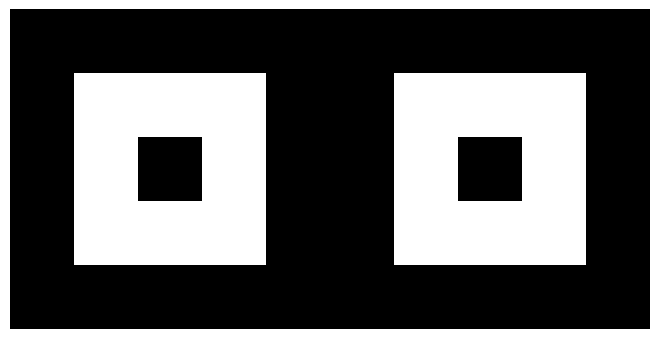

[[[0. 0. 0. 0. 0.]
  [0. 1. 1. 1. 0.]
  [0. 1. 0. 1. 0.]
  [0. 1. 1. 1. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 1. 0. 1. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]]]
[[[0.         0.         0.         0.         0.        ]
  [0.         0.33333333 0.5        0.33333333 0.        ]
  [0.         0.33333333 0.         0.33333333 0.        ]
  [0.         0.33333333 0.5        0.33333333 0.        ]
  [0.         0.         0.         0.         0.        ]]

 [[0.         0.         0.         0.         0.        ]
  [0.         0.         0.5        0.         0.        ]
  [0.         1.         0.         1.         0.        ]
  [0.         0.         0.5        0.         0.        ]
  [0.         0.         0.         0.         0.        ]]]


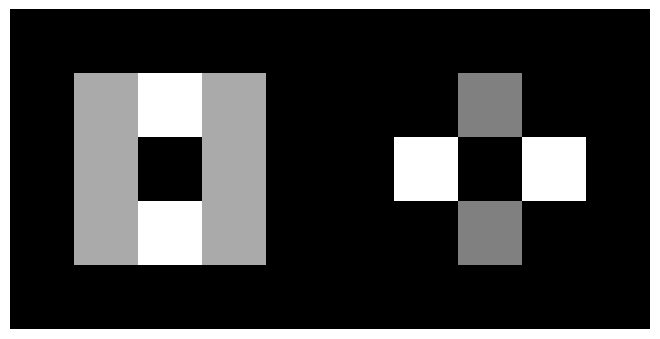

--
[[[       nan 0.         0.         0.                nan]
  [       nan 0.57735027 0.70710678 0.57735027        nan]
  [       nan 0.57735027 0.         0.57735027        nan]
  [       nan 0.57735027 0.70710678 0.57735027        nan]
  [       nan 0.         0.         0.                nan]]

 [[       nan 0.         0.         0.                nan]
  [       nan 0.         0.70710678 0.                nan]
  [       nan 1.         0.         1.                nan]
  [       nan 0.         0.70710678 0.                nan]
  [       nan 0.         0.         0.                nan]]]


d:\git\rd\dynaspike\nb\tests\spikeml\datasets\../../../../src\spikeml\utils\vector.py:242: RuntimeWarning: invalid value encountered in divide
  a = a / n[:,None]


NameError: name 'la' is not defined

In [6]:
a = make_glyph(Glyph.SQUARE, shape=(5,5), rescale=True)
#a = np.zeros((5,5), dtype=np.uint8)
#w,h = a.shape[1],a.shape[0]
#cv2.rectangle(a, (w//4,h//4), (3*w//4,3*h//4), color=color, thickness=-1)

print(a.shape)
print(a)
a_ = normalize(a)
print(a_)
a_ = normalize(a, 2)
print(a_)

show_imgs([a, a_], ncols=2)

aa = make_glyphs([Glyph.SQUARE, Glyph.CIRC], shape=(5,5))
aa_ = np.array(aa)
print(aa_)
aa1 = normalize_all(aa_, 1)
print(aa1)
show_imgs(aa1, ncols=2)
print('--')
aa2 = normalize_all(aa_, 2)
print(aa2)
print(la.norm(aa_, axis=(-2,-1)))


In [ ]:
#show_all_glyph_txs()